# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test3 sno validation

Notebook equivalent of `tests/3_solar/test3_sno_validation.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `solar` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `solar` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test3_sno_validation"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "3_solar" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\3_solar\test3_sno_validation.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `solar` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "solar" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\solar\test3_sno_validation


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_sno_input_files_are_consistent`

**What is checked:** Sno input files are consistent behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; legacy/reference-data comparisons may fail if optional reference inputs or conventions change.


In [4]:
run_notebook_test(TEST_MODULE.test_sno_input_files_are_consistent)


Running test_sno_input_files_are_consistent ...

SNO input file consistency:
8B: torch rows=74, legacy rows=74, max |delta SNO|=0.000e+00
hep: torch rows=51, legacy rows=51, max |delta SNO|=0.000e+00
------------------------------------------------------------------------------------------
PASSED: test_sno_input_files_are_consistent


## Test: `test_torch_legacy_psolar_precision`

**What is checked:** Torch legacy psolar precision behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; legacy/reference-data comparisons may fail if optional reference inputs or conventions change.


In [5]:
run_notebook_test(TEST_MODULE.test_torch_legacy_psolar_precision)


Running test_torch_legacy_psolar_precision ...

Torch vs legacy solar probability precision:
Warning!: Python module pyslha not found, disabling slha reading routines
8B: max |P_torch - P_legacy|=9.992e-16, RMS=4.184e-16, max normalization error=4.441e-16
hep: max |P_torch - P_legacy|=1.443e-15, RMS=4.016e-16, max normalization error=4.441e-16
------------------------------------------------------------------------------------------
PASSED: test_torch_legacy_psolar_precision


## Test: `test_sno_reference_curve_agreement`

**What is checked:** Sno reference curve agreement behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; legacy/reference-data comparisons may fail if optional reference inputs or conventions change.


In [6]:
run_notebook_test(TEST_MODULE.test_sno_reference_curve_agreement)


Running test_sno_reference_curve_agreement ...

Torch electron survival probability compared with SNO reference curves:
8B: max |Pee_torch - Pee_SNO|=6.059e-03, RMS=3.716e-03
hep: max |Pee_torch - Pee_SNO|=5.006e-03, RMS=3.452e-03
------------------------------------------------------------------------------------------
PASSED: test_sno_reference_curve_agreement


## Test: `test_distorted_spectrum_precision`

**What is checked:** Distorted spectrum precision behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_distorted_spectrum_precision)


Running test_distorted_spectrum_precision ...

Distorted spectrum precision:
8B: max |distorted_torch - distorted_legacy|=1.041e-16, max relative=2.066e-15
hep: max |distorted_torch - distorted_legacy|=1.318e-16, max relative=3.317e-15
------------------------------------------------------------------------------------------
PASSED: test_distorted_spectrum_precision


## Plot: `plot_density_and_fractions()`

**What is checked:** Density and fractions behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (solar_sno_density_and_fractions.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_density_and_fractions()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `solar_sno_density_and_fractions.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_density_and_fractions() ...
Saved plot: V:\output\test\solar\test3_sno_validation\plot_density_and_fractions_figure_001.png


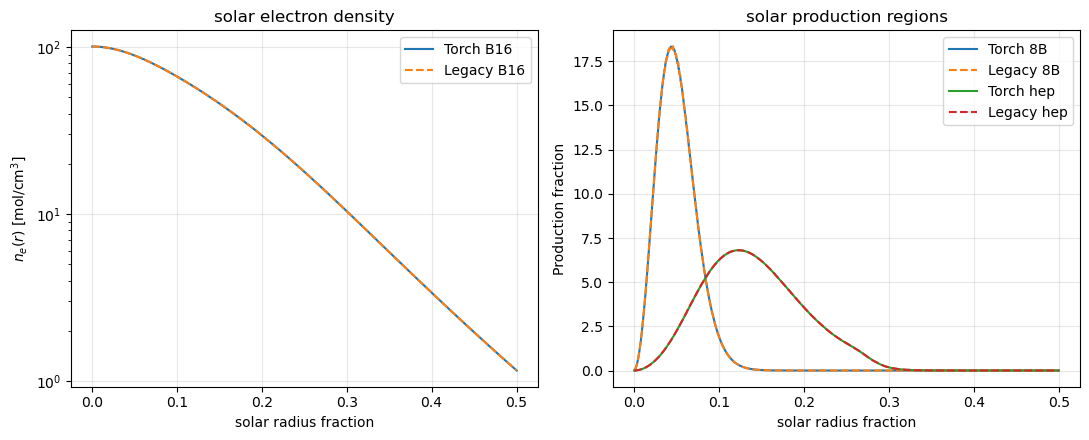

PASSED: plot_density_and_fractions()


In [8]:
run_notebook_call('plot_density_and_fractions()', lambda: TEST_MODULE.plot_density_and_fractions())


## Plot: `plot_probabilities('8B')`

**What is checked:** Probabilities behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (solar_sno_probabilities_{source}.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; normalization failures often point to probability conservation or broadcasting issues; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_probabilities('8B')`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `solar_sno_probabilities_{source}.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_probabilities('8B') ...
Saved plot: V:\output\test\solar\test3_sno_validation\plot_probabilities__8B_figure_001.png


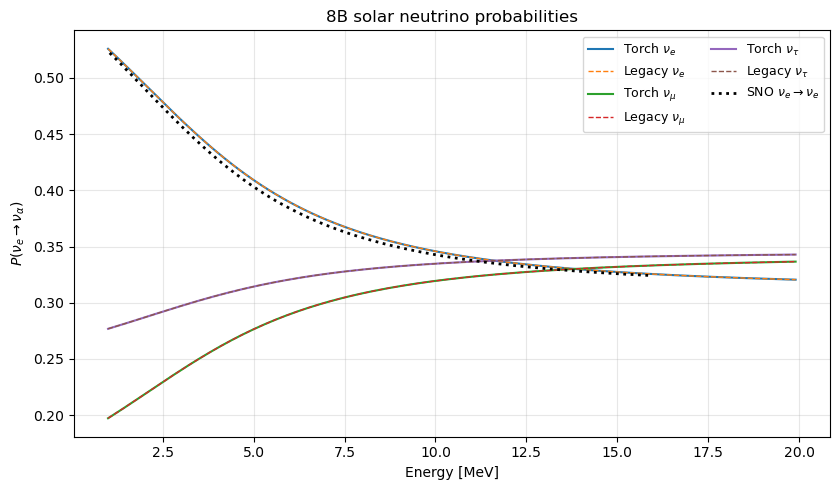

PASSED: plot_probabilities('8B')


In [9]:
run_notebook_call("plot_probabilities('8B')", lambda: TEST_MODULE.plot_probabilities('8B'))


## Plot: `plot_probabilities('hep')`

**What is checked:** Probabilities behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (solar_sno_probabilities_{source}.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; normalization failures often point to probability conservation or broadcasting issues; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_probabilities('hep')`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `solar_sno_probabilities_{source}.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_probabilities('hep') ...
Saved plot: V:\output\test\solar\test3_sno_validation\plot_probabilities__hep_figure_001.png


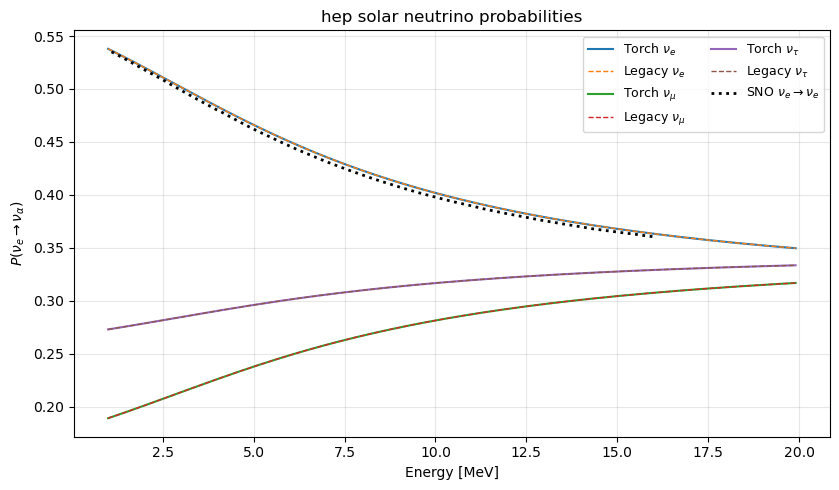

PASSED: plot_probabilities('hep')


In [10]:
run_notebook_call("plot_probabilities('hep')", lambda: TEST_MODULE.plot_probabilities('hep'))


## Plot: `plot_distorted_spectrum('8B')`

**What is checked:** Distorted spectrum behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (solar_sno_distorted_spectrum_{source}.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_distorted_spectrum('8B')`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `solar_sno_distorted_spectrum_{source}.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_distorted_spectrum('8B') ...
Saved plot: V:\output\test\solar\test3_sno_validation\plot_distorted_spectrum__8B_figure_001.png


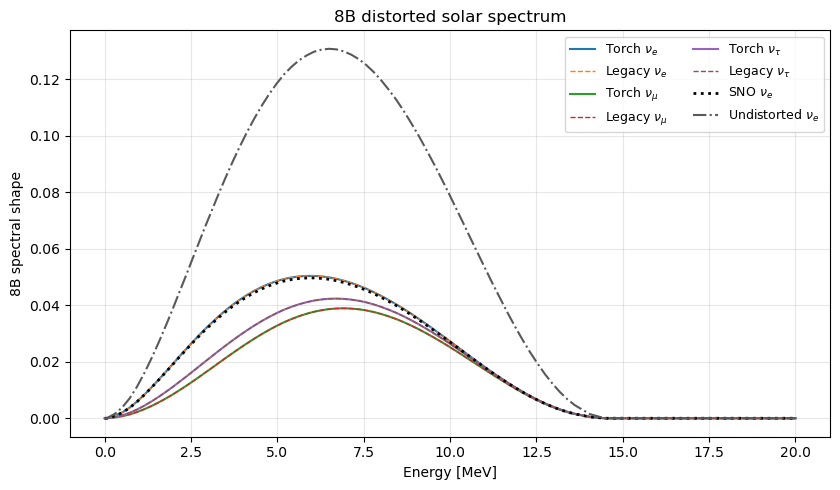

PASSED: plot_distorted_spectrum('8B')


In [11]:
run_notebook_call("plot_distorted_spectrum('8B')", lambda: TEST_MODULE.plot_distorted_spectrum('8B'))


## Plot: `plot_distorted_spectrum('hep')`

**What is checked:** Distorted spectrum behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (solar_sno_distorted_spectrum_{source}.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; missing solar reference tables or changed interpolation grids can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_distorted_spectrum('hep')`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `solar_sno_distorted_spectrum_{source}.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_distorted_spectrum('hep') ...
Saved plot: V:\output\test\solar\test3_sno_validation\plot_distorted_spectrum__hep_figure_001.png


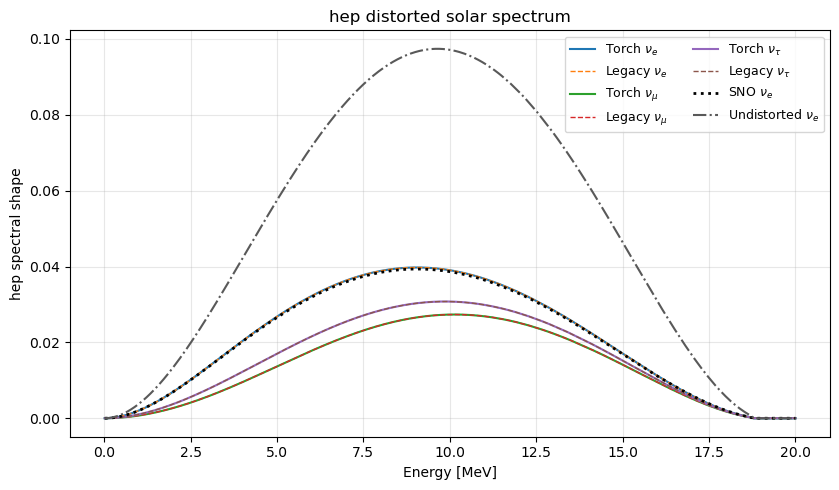

PASSED: plot_distorted_spectrum('hep')


In [12]:
run_notebook_call("plot_distorted_spectrum('hep')", lambda: TEST_MODULE.plot_distorted_spectrum('hep'))
